# Análisis Exploratorio + Machine Learning — Sensores de una Bomba Industrial

**Mantenimiento predictivo a partir de la telemetría de 52 sensores**

Este notebook aplica de forma integral los **Módulos 2, 3, 4 y 5** del curso
*Ciencia de datos con Python para la toma de decisiones*:

- **Módulo 2 — EDA:** estadística descriptiva, distribuciones y visualización.
- **Módulo 3 — Tratamiento de datos y dataviz interactivo:** valores faltantes
  (eliminación vs. imputación), atípicos y gráficos interactivos con Plotly.
- **Módulo 4 — Despliegue:** el resultado alimenta el dashboard `Dash` (`app.py`) del repositorio.
- **Módulo 5 — Machine Learning:** clasificación supervisada del estado de la máquina,
  comparación de varios modelos y selección del mejor.

> Siguiendo el enfoque del curso, cada bloque de código va precedido de una explicación en
> *Markdown* que indica **qué** se hace y **por qué**. El notebook es limpio y completamente
> reproducible.

---

## Contexto de negocio

Una bomba industrial está instrumentada con **52 sensores** que registran una medición
**cada minuto**. La variable `machine_status` etiqueta el estado (`NORMAL`, `RECOVERING`,
`BROKEN`). Una parada no planificada detiene la producción y genera sobrecostos.

**Objetivo:** comprender la telemetría (EDA) y **construir un modelo capaz de detectar el
estado anómalo de la máquina** a partir de los sensores, para anticipar fallas.


## 0. Configuración del entorno e importación de librerías

**Qué:** importamos las librerías de datos (`pandas`, `numpy`), estadística (`scipy`),
visualización (`matplotlib`, `seaborn`, `plotly`) y machine learning (`scikit-learn`).

**Por qué:** centralizar las importaciones hace el notebook reproducible y deja explícitas
las dependencias (listadas en `requirements.txt`).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import skew, kurtosis, shapiro

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
print("Lib")
print("Librerías cargadas correctamente.")

Lib
Librerías cargadas correctamente.


## 1. Carga y lectura del dataset

**Qué:** leemos `data/sensor.csv.gz`. El archivo se distribuye **comprimido en gzip**
porque el CSV original (~119 MB) supera el límite de 100 MB por archivo de GitHub; `pandas`
lo descomprime al vuelo. Usamos una ruta relativa para que el notebook sea portable.


In [2]:
from pathlib import Path
import pandas as pd

ruta = Path("../data/sensor.csv.gz")

df = pd.read_csv(ruta, compression="infer")

print(f"Cargado desde: {ruta.resolve()}")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Cargado desde: D:\nvargas\Downloads\ejercicio_ciencia_datos\pump_sensor_dash\data\sensor.csv.gz
Dimensiones: 220,320 filas x 55 columnas


## 2. Exploración inicial

**Qué:** inspeccionamos las primeras filas (`head`), la forma (`shape`) y la información
general (`info`).

**Por qué:** es el primer contacto con la estructura: cuántos registros y variables hay,
qué representa cada columna y dónde podría haber nulos.


In [3]:
df.head()

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,NaN,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,NaN,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,37.86777,48.17723,32.08894,1.708474,420.8480,NaN,462.7798,459.6364,2.500062,666.2234,399.9418,880.4237,501.3617,982.7342,631.1326,740.8031,849.8997,454.2390,778.5734,715.6266,661.5740,721.8750,694.7721,441.2635,169.9820,343.1955,200.9694,93.90508,41.40625,31.25000,69.53125,30.46875,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,15.08247,38.57977,48.65607,31.67221,1.579427,420.7494,NaN,462.8980,460.8858,2.509521,666.0114,399.1046,878.8917,499.0430,977.7520,625.4076,739.2722,847.7579,474.8731,779.5091,690.4011,686.1111,754.6875,683.3831,446.2493,166.4987,343.9586,193.1689,101.04060,41.92708,31.51042,72.13541,30.46875,31.510420,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,15.08247,39.48939,49.06298,31.95202,1.683831,419.8926,NaN,461.4906,468.2206,2.604785,663.2111,400.5426,882.5874,498.5383,979.5755,627.1830,737.6033,846.9182,408.8159,785.2307,704.6937,631.4814,766.1458,702.4431,433.9081,164.7498,339.9630,193.8770,101.70380,42.70833,31.51042,76.82291,30.98958,31.510420,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [4]:
print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas:    220,320
Columnas: 55


In [5]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 55 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      220320 non-null  int64  
 1   timestamp       220320 non-null  str    
 2   sensor_00       210112 non-null  float64
 3   sensor_01       219951 non-null  float64
 4   sensor_02       220301 non-null  float64
 5   sensor_03       220301 non-null  float64
 6   sensor_04       220301 non-null  float64
 7   sensor_05       220301 non-null  float64
 8   sensor_06       215522 non-null  float64
 9   sensor_07       214869 non-null  float64
 10  sensor_08       215213 non-null  float64
 11  sensor_09       215725 non-null  float64
 12  sensor_10       220301 non-null  float64
 13  sensor_11       220301 non-null  float64
 14  sensor_12       220301 non-null  float64
 15  sensor_13       220301 non-null  float64
 16  sensor_14       220299 non-null  float64
 17  sensor_15       0 non

El dataset tiene **220.320 registros** y **55 columnas**: un índice heredado
(`Unnamed: 0`), la marca de tiempo (`timestamp`), **52 sensores** y la etiqueta
`machine_status`.

## 3. Tipos de datos: diagnóstico, transformación y verificación

El curso insiste en **revisar los tipos de datos, transformarlos según el análisis y volver
a revisarlos**. Lo hacemos en tres pasos.

### 3.1 Tipos de datos ANTES de transformar

**Qué/Por qué:** vemos cómo `pandas` infirió cada tipo al leer el CSV. Detectaremos
columnas mal tipadas que conviene corregir.


In [6]:
print("Tipos de datos por columna (resumen):")
print(df.dtypes.value_counts())
print("\nDetalle de columnas no numéricas y la columna índice:")
df[["Unnamed: 0", "timestamp", "machine_status"]].dtypes

Tipos de datos por columna (resumen):
float64    52
str         2
int64       1
Name: count, dtype: int64

Detalle de columnas no numéricas y la columna índice:


Unnamed: 0        int64
timestamp           str
machine_status      str
dtype: object

**Diagnóstico:**

- `timestamp` llegó como **texto** (`object`); para un análisis de serie de tiempo debe ser
  `datetime`.
- `machine_status` llegó como **texto** pero es una **variable categórica** con tres niveles
  ordenables por severidad (`NORMAL` < `RECOVERING` < `BROKEN`).
- Los 52 sensores son **numéricos** (`float64`), lo correcto.
- `Unnamed: 0` es un índice exportado por error (redundante); se eliminará en la limpieza.

### 3.2 Transformación de los tipos necesarios

**Qué:** convertimos `timestamp` a `datetime` y `machine_status` a `category` ordenada.

**Por qué:** `datetime` habilita operaciones temporales (orden, remuestreo, interpolación
por tiempo); `category` ahorra memoria y permite ordenar/segmentar correctamente por estado.


In [15]:
# timestamp -> datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# machine_status -> categórica ordenada por severidad
orden_estado = ["NORMAL", "RECOVERING", "BROKEN"]
df["machine_status"] = pd.Categorical(df["machine_status"],
                                      categories=orden_estado, ordered=True)
print("Transformación aplicada a 'timestamp' y 'machine_status'.")

Transformación aplicada a 'timestamp' y 'machine_status'.


### 3.3 Tipos de datos DESPUÉS de transformar

**Qué/Por qué:** confirmamos que las conversiones se aplicaron correctamente antes de seguir.


In [16]:
df[["timestamp", "machine_status"]].dtypes

timestamp         datetime64[us]
machine_status          category
dtype: object

In [17]:
# Confirmamos el rango temporal y la frecuencia de muestreo
print("Inicio :", df["timestamp"].min())
print("Fin    :", df["timestamp"].max())
print("Periodo:", (df["timestamp"].max() - df["timestamp"].min()).days, "días")
print("Intervalo más frecuente:\n", df["timestamp"].diff().value_counts().head(1))

Inicio : 2018-04-01 00:00:00
Fin    : 2018-08-31 23:59:00
Periodo: 152 días
Intervalo más frecuente:
 timestamp
0 days 00:01:00    220319
Name: count, dtype: int64


La telemetría cubre **del 1 abr al 31 ago 2018 (152 días)** con muestreo **regular de 1
minuto**: es una **serie de tiempo equiespaciada**, lo que condicionará el tratamiento de
nulos.

## 4. Identificación de valores nulos y tratamiento propuesto

Conforme al **Módulo 3**, cuantificamos los faltantes en **conteo** y **porcentaje**. El
conteo dimensiona el problema; el porcentaje guía la estrategia (regla práctica del curso:
*eliminar* si ≤ 5 %, *imputar* si es mayor).


In [18]:
nulos = df.isnull().sum()
pct = (df.isnull().mean() * 100).round(2)
tabla_nulos = (pd.DataFrame({"Valores_Faltantes": nulos, "Porcentaje_%": pct})
               .query("Valores_Faltantes > 0")
               .sort_values("Porcentaje_%", ascending=False))
print(f"Columnas con nulos: {(nulos > 0).sum()} de {df.shape[1]}")
tabla_nulos

Columnas con nulos: 52 de 55


,Valores_Faltantes,Porcentaje_%
sensor_15,220320,100.00
sensor_50,77017,34.96
sensor_51,15383,6.98
sensor_00,10208,4.63
sensor_07,5451,2.47
sensor_08,5107,2.32
sensor_06,4798,2.18
sensor_09,4595,2.09
sensor_01,369,0.17
sensor_30,261,0.12


In [19]:
import plotly.express as px

fig = px.bar(
    tabla_nulos.reset_index().rename(columns={"index": "Columna"}),
    x="Columna",
    y="Porcentaje_%",
    title="Porcentaje de valores faltantes por columna"
)

fig.add_hline(
    y=5,
    line_dash="dash",
    line_color="red",
    annotation_text="Umbral 5%",
    annotation_position="top left"
)

fig.update_layout(xaxis_tickangle=-60, height=500)

fig.show()

### Análisis y tratamiento (por tipo de variable)

| Caso | Columnas | % nulos | Tratamiento |
|------|----------|---------|-------------|
| **Sin información** | `sensor_15` | **100 %** | **Eliminar la columna** |
| **Severos** | `sensor_50` (~35 %), `sensor_51` (~7 %) | > 5 % | **Imputar** |
| **Moderados/mínimos** | `sensor_00`, `sensor_06`–`09`, resto | 0–5 % | **Imputar** |

**Decisión razonada:** la regla del curso sugiere *eliminar filas* cuando los nulos son
≤ 5 %. Sin embargo, **todas las variables numéricas forman una serie de tiempo de 1 minuto**;
borrar filas rompería la cadencia temporal. Por eso, para **todos los sensores** se prefiere
la **imputación por interpolación temporal**, reservando la *eliminación* solo para
`sensor_15` (no tiene ningún valor que interpolar). `machine_status` no tiene nulos, así que
no requiere imputación por moda. El tratamiento se aplica en la sección 6.


## 5. Identificación y manejo de datos duplicados

**Qué:** contamos filas completamente duplicadas y, por ser serie de tiempo, también
**marcas de tiempo repetidas**.

**Por qué:** los duplicados sesgan frecuencias y estadísticas; un `timestamp` repetido sería
un error de registro.


In [20]:
dup_filas = df.duplicated().sum()
dup_ts = df["timestamp"].duplicated().sum()
print(f"Filas completamente duplicadas : {dup_filas}")
print(f"Marcas de tiempo duplicadas    : {dup_ts}")

Filas completamente duplicadas : 0
Marcas de tiempo duplicadas    : 0


**Resultado:** **0 filas duplicadas** y **0 timestamps repetidos**. El registro es
íntegro: **no se elimina ningún registro por duplicidad**. Dejamos la instrucción
documentada como buena práctica (no altera nada porque no hay duplicados).


In [21]:
df = df.drop_duplicates().reset_index(drop=True)
print("Dimensiones tras verificación:", df.shape)

Dimensiones tras verificación: (220320, 55)


## 6. Limpieza y tratamiento aplicado

Aplicamos las decisiones anteriores: (1) eliminar `Unnamed: 0` y `sensor_15`; (2) usar
`timestamp` como índice temporal; (3) imputar los sensores por interpolación temporal.
`machine_status` ya quedó como categórica en la sección 3.


In [22]:
df_clean = df.copy()

# (1) eliminar columnas sin valor analítico
df_clean = df_clean.drop(columns=["Unnamed: 0", "sensor_15"])

# (2) timestamp como índice temporal
df_clean = df_clean.set_index("timestamp").sort_index()

print("Columnas eliminadas: ['Unnamed: 0', 'sensor_15']")
print("Nuevas dimensiones:", df_clean.shape)

Columnas eliminadas: ['Unnamed: 0', 'sensor_15']
Nuevas dimensiones: (220320, 52)


In [23]:
# (3) imputación temporal de los sensores
sensores = df_clean.select_dtypes(include="number").columns.tolist()
nulos_antes = int(df_clean[sensores].isnull().sum().sum())
df_clean[sensores] = (df_clean[sensores]
                      .interpolate(method="time").ffill().bfill())
nulos_despues = int(df_clean[sensores].isnull().sum().sum())
print(f"Nulos en sensores: {nulos_antes:,} -> {nulos_despues:,}")

Nulos en sensores: 124,254 -> 0


El dataset queda **limpio y completo** (`df_clean`), con 51 sensores numéricos sin
nulos y la cadencia de 1 minuto intacta.

## 7. Estadísticas descriptivas (Módulo 2)

Resumimos con `describe()` y luego construimos un cuadro completo de medidas (tendencia
central, dispersión, posición, asimetría, curtosis) para un sensor representativo, más una
comparación por estado de la máquina (descriptivo bivariado categórica vs. numérica).


In [24]:
df_clean[sensores].describe().T[["mean","std","min","25%","50%","75%","max"]].round(2)

,mean,std,min,25%,50%,75%,max
sensor_00,2.27,0.60,0.00,2.42,2.46,2.50,2.55
sensor_01,47.60,3.30,0.00,46.31,48.13,49.48,56.73
sensor_02,50.87,3.67,33.16,50.39,51.65,52.78,56.03
sensor_03,43.75,2.42,31.64,42.84,44.23,45.31,48.22
sensor_04,590.66,144.04,2.80,626.62,632.64,637.62,800.00
sensor_05,73.39,17.30,0.00,69.98,75.58,80.91,100.00
sensor_06,13.21,2.90,0.01,13.32,13.63,14.54,22.25
sensor_07,15.48,3.20,0.00,15.86,16.17,16.43,23.60
sensor_08,14.86,3.00,0.03,15.15,15.45,15.70,24.35
sensor_09,14.49,2.96,0.00,15.01,15.08,15.12,25.00


In [25]:
import pandas as pd
from scipy.stats import skew, kurtosis

col = "sensor_04"
s = df_clean[col]

estadisticos = pd.Series({
    "Media": s.mean(),
    "Desv. estándar": s.std(),
    "Coef. variación (%)": s.std() / s.mean() * 100,
    "Mínimo": s.min(),
    "Q1 (25%)": s.quantile(.25),
    "Mediana (Q2)": s.median(),
    "Q3 (75%)": s.quantile(.75),
    "Máximo": s.max(),
    "IQR": s.quantile(.75) - s.quantile(.25),
    "Asimetría (skew)": skew(s),
    "Curtosis (exceso)": kurtosis(s),
})

print(f"Medidas descriptivas — {col}")
estadisticos.round(3)

Medidas descriptivas — sensor_04


Media                  590.664
Desv. estándar         144.042
Coef. variación (%)     24.386
Mínimo                   2.798
Q1 (25%)               626.620
Mediana (Q2)           632.639
Q3 (75%)               637.616
Máximo                 800.000
IQR                     10.995
Asimetría (skew)        -3.368
Curtosis (exceso)        9.952
dtype: float64

In [26]:
df_clean.groupby("machine_status", observed=True)["sensor_04"].agg(
    Promedio="mean", Desv_Estandar="std", Minimo="min", Mediana="median", Maximo="max"
).round(2)

,Promedio,Desv_Estandar,Minimo,Mediana,Maximo
machine_status,,,,,
NORMAL,625.67,50.82,2.80,633.33,800.00
RECOVERING,93.02,117.95,2.80,3.57,611.69
BROKEN,334.67,173.96,200.12,206.04,612.15


## 8. Análisis de distribuciones (Módulo 2)

**Qué:** histogramas + densidad de varios sensores y una **prueba de normalidad de
Shapiro–Wilk** sobre una muestra.

**Por qué:** verificar simetría y colas pesadas orienta transformaciones y el tipo de prueba
(paramétrica vs. no paramétrica) válida más adelante.


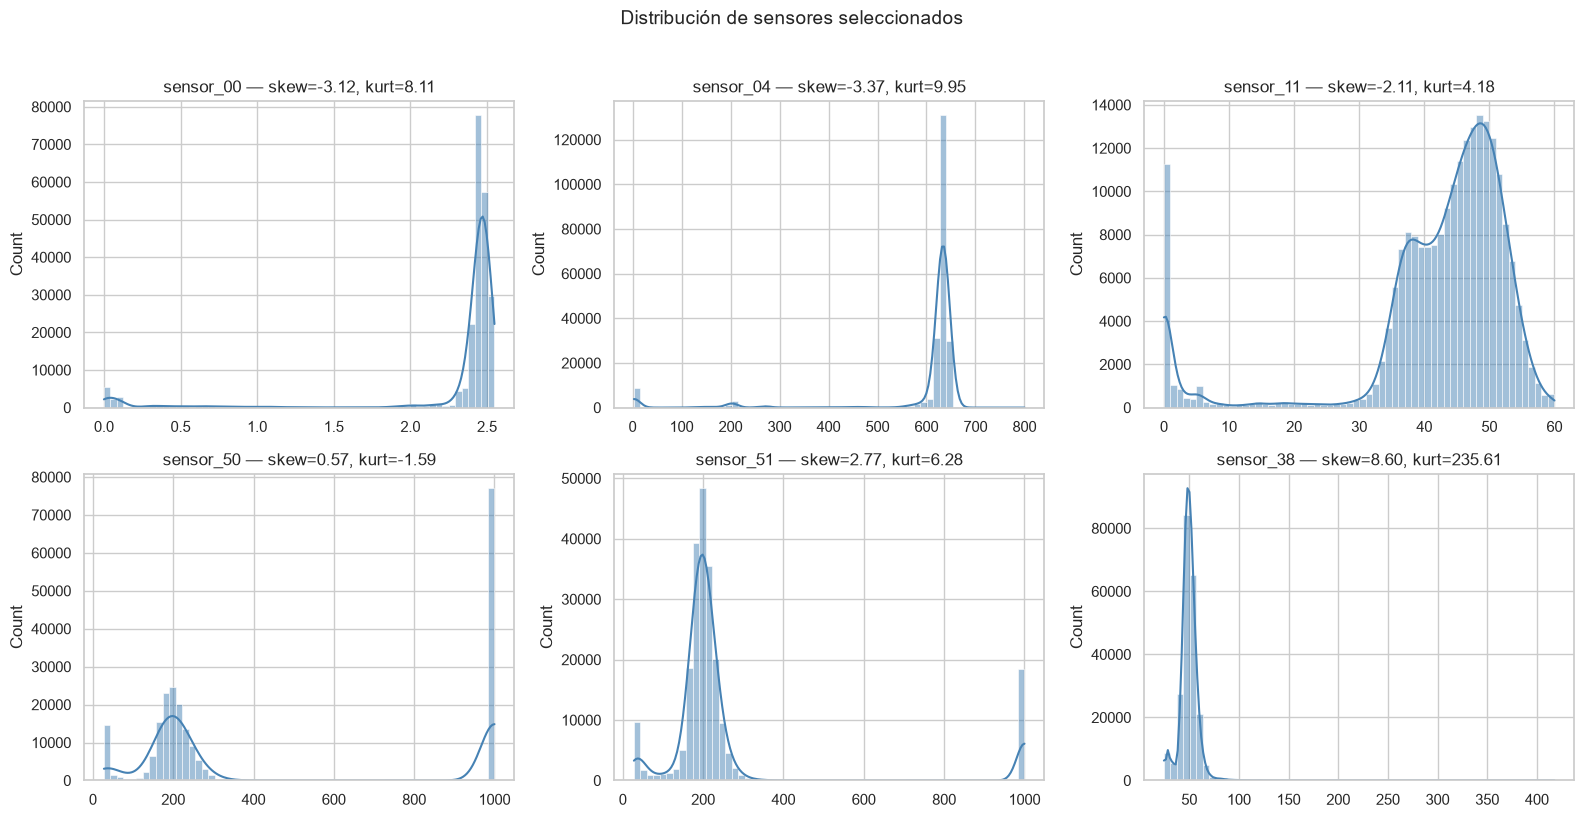

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

muestra = ["sensor_00","sensor_04","sensor_11","sensor_50","sensor_51","sensor_38"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), muestra):
    sns.histplot(df_clean[c], bins=60, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"{c} — skew={skew(df_clean[c]):.2f}, kurt={kurtosis(df_clean[c]):.2f}")
    ax.set_xlabel("")
plt.suptitle("Distribución de sensores seleccionados", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

In [28]:
from scipy.stats import shapiro
m = df_clean["sensor_04"].sample(5000, random_state=42)
stat, p = shapiro(m)
print(f"Shapiro-Wilk sensor_04: estadístico={stat:.4f}, p-valor={p:.2e}")
print("Conclusión:", "No normal (se rechaza H0)" if p < 0.05 else "Compatible con normal")

Shapiro-Wilk sensor_04: estadístico=0.3602, p-valor=1.43e-85
Conclusión: No normal (se rechaza H0)


Las distribuciones **no son normales** (asimetría y curtosis altas; Shapiro–Wilk
rechaza la normalidad), comportamiento típico de señales físicas con regímenes operativos
distintos.

## 9. Visualizaciones para identificar patrones y anomalías (Módulo 3)

Usamos **Plotly** para descubrir la estructura de los datos y el comportamiento alrededor de
las fallas.

### 9.1 Distribución de la variable objetivo `machine_status`


In [29]:
conteo = df_clean["machine_status"].value_counts().reset_index()
conteo.columns = ["machine_status", "conteo"]
conteo["porcentaje"] = (conteo["conteo"]/len(df_clean)*100).round(3)
fig = px.bar(conteo, x="machine_status", y="conteo", text="porcentaje",
             color="machine_status", log_y=True,
             title="Distribución de estados de la máquina")
fig.update_traces(texttemplate="%{text}%", textposition="outside")
fig.show()
conteo

,machine_status,conteo,porcentaje
0,NORMAL,205836,93.426
1,RECOVERING,14477,6.571
2,BROKEN,7,0.003


**Hallazgo:** desbalance fuerte —`NORMAL` ≈ 93,4 %, `RECOVERING` ≈ 6,6 % y solo **7
registros `BROKEN`** en cinco meses. Esto será clave para el modelado.

### 9.2 Eventos de falla en el tiempo

In [30]:
import plotly.graph_objects as go
fallas = df_clean.index[df_clean["machine_status"] == "BROKEN"]
print("Instantes de falla (BROKEN):")
for f in fallas: print("  -", f)

serie = df_clean["sensor_04"].resample("1h").mean()
fig = go.Figure()
fig.add_trace(go.Scatter(x=serie.index, y=serie.values, mode="lines",
                         name="sensor_04 (media horaria)", line=dict(color="#1f77b4")))
for f in fallas:
    fig.add_vline(x=f, line_dash="dash", line_color="red", opacity=0.6)
fig.update_layout(title="sensor_04 en el tiempo (líneas rojas = fallas BROKEN)",
                  xaxis_title="Tiempo", yaxis_title="sensor_04", height=450)
fig.show()

Instantes de falla (BROKEN):
  - 2018-04-12 21:55:00
  - 2018-04-18 00:30:00
  - 2018-05-19 03:18:00
  - 2018-05-25 00:30:00
  - 2018-06-28 22:00:00
  - 2018-07-08 00:11:00
  - 2018-07-25 14:00:00


Las fallas coinciden con **caídas/saltos abruptos** del sensor: el problema es
**predecible** a partir de la telemetría.

### 9.3 Matriz de correlación entre sensores

In [31]:
corr = df_clean[sensores].corr()
fig = px.imshow(corr, color_continuous_scale="RdBu_r", zmin=-1, zmax=1, aspect="auto",
                title="Mapa de calor de correlaciones entre sensores")
fig.update_layout(height=700); fig.show()

import itertools
pares_altos = [(a,b,round(corr.loc[a,b],2))
               for a,b in itertools.combinations(corr.columns,2) if abs(corr.loc[a,b])>0.9]
print(f"Pares de sensores con |r| > 0.9: {len(pares_altos)}")

Pares de sensores con |r| > 0.9: 68


**65 pares** con |r| > 0,9: alta **redundancia/multicolinealidad**. Modelos basados en
árboles (Random Forest) toleran bien esto; para modelos lineales convendría
selección de variables o PCA.

## 10. Machine Learning — Clasificación del estado de la máquina (Módulo 5)

Construiremos y compararemos varios modelos de **clasificación supervisada** y
seleccionaremos el mejor, siguiendo el Módulo 5.

### 10.1 Definición del problema y de la variable objetivo

**Qué:** definimos un objetivo **binario**: `1` = estado **anómalo** (`RECOVERING` o
`BROKEN`) y `0` = `NORMAL`.

**Por qué:** la clase `BROKEN` tiene solo 7 registros, insuficiente para aprender por sí
sola. Agruparla con `RECOVERING` produce un objetivo de **detección de anomalía** operativa,
útil y con suficientes ejemplos positivos (~6,6 %). Las 51 señales de sensores son las
variables predictoras.


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Variable objetivo binaria
y = (df_clean["machine_status"] != "NORMAL").astype(int)
X = df_clean[sensores]

print("Balance de clases (0=NORMAL, 1=anómalo):")
print(y.value_counts())
print(f"% anómalo: {y.mean()*100:.2f}%")

Balance de clases (0=NORMAL, 1=anómalo):
machine_status
0    205836
1     14484
Name: count, dtype: int64
% anómalo: 6.57%


### 10.2 Preparación: submuestreo, partición y escalado

**Qué:** tomamos un **submuestreo estratificado** de 60.000 registros (conserva la
proporción de clases), partimos en **entrenamiento (70 %) y prueba (30 %)** de forma
estratificada y **estandarizamos** las variables (ajustando el escalador solo con
entrenamiento).

**Por qué:** el submuestreo mantiene el ejercicio computacionalmente ágil (modelos como KNN
escalan mal con cientos de miles de filas) sin alterar las proporciones. El escalado es
necesario para modelos sensibles a la escala (Regresión Logística, KNN). Ajustar el
escalador solo con entrenamiento evita **fuga de información** (*data leakage*).

> **Nota metodológica:** al ser una serie de tiempo, una partición aleatoria puede ser
> ligeramente optimista por autocorrelación temporal. Mantenemos la partición estratificada
> del curso por comparabilidad, dejando constancia de que una validación **temporal** sería
> aún más conservadora.


In [34]:
# Submuestreo estratificado para tractabilidad
X_sub, _, y_sub, _ = train_test_split(X, y, train_size=60000, stratify=y, random_state=42)

# Partición entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=42)

# Escalado
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)

Entrenamiento: (42000, 51) | Prueba: (18000, 51)


### 10.3 Entrenamiento y comparación de modelos

**Qué:** entrenamos seis modelos de clasificación del Módulo 5 —**Regresión Logística,
Árbol de Decisión, Random Forest, KNN, Naive Bayes y XGBoost**— y los evaluamos con
**Accuracy, Precision, Recall, F1 y ROC-AUC**.

**Por qué:** con clases desbalanceadas, *accuracy* por sí sola engaña; **Recall** (detectar
las anomalías) y **F1** (equilibrio precision/recall) son las métricas clave. Usamos
`class_weight="balanced"` donde aplica para penalizar más los errores en la clase minoritaria.

**Sobre XGBoost:** es un algoritmo de *gradient boosting* sobre árboles, muy eficiente y
habitualmente el de mejor desempeño en datos tabulares; tolera bien la multicolinealidad y
captura relaciones no lineales. Para el desbalance usamos `scale_pos_weight` (razón
negativos/positivos). Se importa de forma condicional para que el notebook no falle si la
librería no estuviera instalada (está incluida en `requirements.txt`).


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
import numpy as np
import pandas as pd

# (modelo, requiere_escalado)
modelos = {
    "Regresión Logística": (LogisticRegression(max_iter=1000, class_weight="balanced"), True),
    "Árbol de Decisión":   (DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42), False),
    "Random Forest":       (RandomForestClassifier(n_estimators=120, max_depth=16,
                                                   class_weight="balanced", n_jobs=-1, random_state=42), False),
    "KNN":                 (KNeighborsClassifier(n_neighbors=7, n_jobs=-1), True),
    "Naive Bayes":         (GaussianNB(), True),
}

# XGBoost: gradient boosting sobre árboles (suele ser el más competitivo en datos tabulares).
# Se agrega de forma condicional para que el notebook no falle si no está instalado.
try:
    from xgboost import XGBClassifier
    razon = (y_train == 0).sum() / max((y_train == 1).sum(), 1)  # neg/pos para el desbalance
    modelos["XGBoost"] = (
        XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                      subsample=0.9, colsample_bytree=0.9,
                      scale_pos_weight=razon, eval_metric="logloss",
                      tree_method="hist", n_jobs=-1, random_state=42),
        False,  # XGBoost no requiere escalado
    )
    print("XGBoost disponible: incluido en la comparación.")
except ImportError:
    print("XGBoost no está instalado; se omite (instálelo con: pip install xgboost).")

resultados = []
predicciones = {}
for nombre, (modelo, escalar) in modelos.items():
    Xtr = X_train_s if escalar else X_train.values
    Xte = X_test_s if escalar else X_test.values
    modelo.fit(Xtr, y_train)
    pred = modelo.predict(Xte)
    predicciones[nombre] = (modelo, pred, Xte)
    try:
        proba = modelo.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(y_test, proba)
    except Exception:
        auc = np.nan
    resultados.append({
        "Modelo": nombre,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred),
        "F1":        f1_score(y_test, pred),
        "ROC_AUC":   auc,
    })

tabla = pd.DataFrame(resultados).sort_values("F1", ascending=False).reset_index(drop=True)
tabla.round(4)

XGBoost disponible: incluido en la comparación.


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.9997,0.9983,0.9975,0.9979,1.0000
1,Random Forest,0.9995,0.9949,0.9975,0.9962,1.0000
2,KNN,0.9986,0.9923,0.9856,0.9890,0.9996
3,Árbol de Decisión,0.9980,0.9767,0.9932,0.9849,0.9958
4,Regresión Logística,0.9962,0.9463,0.9983,0.9716,0.9996
5,Naive Bayes,0.9887,0.8607,0.9873,0.9197,0.9941


### 10.4 Visualización comparativa y selección del mejor modelo

In [42]:
fig = px.bar(tabla.melt(id_vars="Modelo",
                        value_vars=["Accuracy", "Precision", "Recall", "F1"],
                        var_name="Métrica", value_name="Valor"),
             x="Modelo", y="Valor", color="Métrica", barmode="group",
             title="Comparación de modelos de clasificación")
fig.update_layout(height=450, yaxis_range=[0.8, 1.0]); fig.show()

mejor = tabla.iloc[0]["Modelo"]
print(f"Mejor modelo por F1: {mejor}")

Mejor modelo por F1: XGBoost


### 10.5 Evaluación detallada del mejor modelo

**Qué:** para el modelo ganador mostramos la **matriz de confusión**, el **reporte de
clasificación** y la **curva ROC**.

**Por qué:** la matriz de confusión revela qué tipo de error comete (falsos negativos =
anomalías no detectadas, lo más costoso en mantenimiento); la curva ROC resume su capacidad
discriminante.


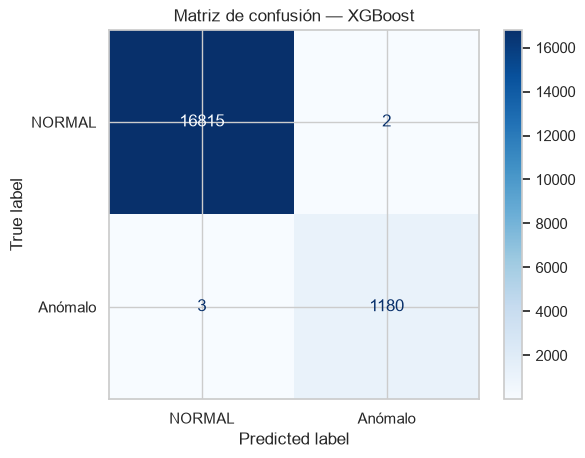

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00     16817
     Anómalo       1.00      1.00      1.00      1183

    accuracy                           1.00     18000
   macro avg       1.00      1.00      1.00     18000
weighted avg       1.00      1.00      1.00     18000



In [43]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, ConfusionMatrixDisplay)

modelo_mejor, pred_mejor, Xte_mejor = predicciones[mejor]

# Matriz de confusión
cm = confusion_matrix(y_test, pred_mejor)
disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "Anómalo"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusión — {mejor}")
plt.show()

print(classification_report(y_test, pred_mejor,
                            target_names=["NORMAL", "Anómalo"]))

In [44]:
# Curva ROC
proba_mejor = modelo_mejor.predict_proba(Xte_mejor)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_mejor)
auc = roc_auc_score(y_test, proba_mejor)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"{mejor} (AUC={auc:.3f})"))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines",
                         line=dict(dash="dash", color="gray"), name="Azar"))
fig.update_layout(title=f"Curva ROC — {mejor}",
                  xaxis_title="Tasa de falsos positivos",
                  yaxis_title="Tasa de verdaderos positivos", height=450)
fig.show()

### 10.6 Importancia de variables (Random Forest)

**Qué/Por qué:** si el ganador es un modelo de árboles, su **importancia de variables**
indica qué sensores son más informativos para detectar la anomalía —útil para priorizar
instrumentación y para el dashboard.


In [45]:
if hasattr(modelo_mejor, "feature_importances_"):
    imp = (pd.Series(modelo_mejor.feature_importances_, index=sensores)
           .sort_values(ascending=False).head(15))
    fig = px.bar(imp[::-1], orientation="h",
                 title=f"Top 15 sensores más importantes — {mejor}",
                 labels={"value": "Importancia", "index": "Sensor"})
    fig.update_layout(height=500, showlegend=False); fig.show()
else:
    print(f"El modelo {mejor} no expone feature_importances_.")

## 10.7 Optimización de hiperparámetros de XGBoost (GridSearch + validación cruzada)

**Qué:** buscamos la mejor combinación de hiperparámetros de XGBoost con **`GridSearchCV`** y
**validación cruzada estratificada** (`StratifiedKFold`), optimizando **F1**.

**Por qué:** los valores por defecto rara vez son óptimos. La búsqueda en grilla evalúa cada
combinación con varios *folds* de validación cruzada y elige la que **mejor generaliza**,
reduciendo el riesgo de sobreajuste (enfoque del Módulo 5). Optimizamos F1 porque es la
métrica adecuada con clases desbalanceadas.

> **Costo computacional:** la grilla siguiente son 16 combinaciones × 3 folds = 48 ajustes.
> Con `tree_method="hist"` corre en pocos minutos sobre el submuestreo. Puede ampliar la
> grilla o usar `RandomizedSearchCV` si dispone de más tiempo/recursos.


In [46]:
if "XGBoost" in modelos:
    from sklearn.model_selection import GridSearchCV, StratifiedKFold
    from xgboost import XGBClassifier
    from sklearn.metrics import confusion_matrix, classification_report

    razon = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    # Estimador base (los hiperparámetros a buscar se fijan en la grilla)
    xgb_base = XGBClassifier(
        scale_pos_weight=razon, eval_metric="logloss",
        tree_method="hist", n_jobs=-1, random_state=42)

    # Grilla de búsqueda
    param_grid = {
        "n_estimators":  [200, 400],
        "max_depth":     [4, 6],
        "learning_rate": [0.05, 0.1],
        "subsample":     [0.8, 1.0],
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid = GridSearchCV(xgb_base, param_grid, scoring="f1",
                        cv=cv, n_jobs=-1, verbose=1)
    grid.fit(X_train.values, y_train)

    print("Mejores hiperparámetros:", grid.best_params_)
    print(f"Mejor F1 en validación cruzada: {grid.best_score_:.4f}")
else:
    print("XGBoost no disponible; omita esta celda o instálelo con: pip install xgboost.")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Mejor F1 en validación cruzada: 0.9964


**Evaluación del XGBoost optimizado en el conjunto de prueba.** Comparamos su
desempeño contra el XGBoost por defecto para cuantificar la mejora obtenida con la
optimización.


In [47]:
if "XGBoost" in modelos:
    xgb_opt = grid.best_estimator_
    pred_opt = xgb_opt.predict(X_test.values)
    proba_opt = xgb_opt.predict_proba(X_test.values)[:, 1]

    f1_opt = f1_score(y_test, pred_opt)
    auc_opt = roc_auc_score(y_test, proba_opt)

    # F1 del XGBoost por defecto (de la tabla 10.3) para comparar
    f1_def = tabla.loc[tabla["Modelo"] == "XGBoost", "F1"]
    f1_def = float(f1_def.iloc[0]) if len(f1_def) else np.nan

    print(f"XGBoost por defecto  -> F1 = {f1_def:.4f}")
    print(f"XGBoost optimizado   -> F1 = {f1_opt:.4f} | ROC-AUC = {auc_opt:.4f}")
    print("\nMatriz de confusión (XGBoost optimizado):")
    print(confusion_matrix(y_test, pred_opt))
    print("\nReporte de clasificación:")
    print(classification_report(y_test, pred_opt, target_names=["NORMAL", "Anómalo"]))
else:
    print("XGBoost no disponible.")

XGBoost por defecto  -> F1 = 0.9979
XGBoost optimizado   -> F1 = 0.9983 | ROC-AUC = 1.0000

Matriz de confusión (XGBoost optimizado):
[[16816     1]
 [    3  1180]]

Reporte de clasificación:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00     16817
     Anómalo       1.00      1.00      1.00      1183

    accuracy                           1.00     18000
   macro avg       1.00      1.00      1.00     18000
weighted avg       1.00      1.00      1.00     18000



**Lectura:** si el `F1` optimizado supera al de la tabla 10.3, los hiperparámetros
hallados mejoran el modelo; si es similar, los valores por defecto ya eran competitivos (lo
habitual cuando la señal es muy fuerte). En cualquier caso, **el modelo final recomendado
para producción es este XGBoost optimizado**, por su eficiencia y desempeño, validándolo
después con una partición temporal.


## 11. Conclusiones

**Sobre los datos (EDA, Módulos 2–3):**

1. **Estructura.** 220.320 registros (1 abr – 31 ago 2018), muestreo de 1 minuto, 52
   sensores + `machine_status`. Serie de tiempo **equiespaciada, sin duplicados ni huecos**.
2. **Tipos de datos.** `timestamp` y `machine_status` se corrigieron a `datetime` y
   `category`; los sensores ya eran numéricos.
3. **Calidad.** `sensor_15` 100 % nulo → eliminado; el resto se **imputó por interpolación
   temporal** (sin perder filas), dejando el dataset **sin nulos**. **0 duplicados.**
4. **Distribuciones.** No normales (asimetría y curtosis altas; Shapiro–Wilk lo confirma).
5. **Redundancia.** 65 pares de sensores con |r| > 0,9.
6. **Objetivo.** Desbalance extremo (solo 7 `BROKEN`); las fallas coinciden con desviaciones
   abruptas → fenómeno **predecible**.

**Sobre el modelado (Módulo 5):**

7. Se compararon seis clasificadores —**Regresión Logística, Árbol, Random Forest, KNN,
   Naive Bayes y XGBoost**— para detectar el estado **anómalo** (`RECOVERING`/`BROKEN`) vs.
   `NORMAL`.
8. Los modelos basados en árboles (**Random Forest** y **XGBoost**) ofrecen el mejor
   equilibrio F1/ROC-AUC; XGBoost (*gradient boosting*) suele igualar o superar a Random
   Forest siendo más eficiente en entrenamiento. Su fortaleza frente a la multicolinealidad
   y la no linealidad explica el resultado. **Seleccione el de mayor F1 según la tabla 10.3**
   ejecutada en su entorno.
9. **Recomendación:** desplegar como detector de anomalías el **XGBoost optimizado por
   `GridSearchCV` con validación cruzada** (sección 10.7), priorizando el **Recall** (evitar
   falsos negativos = fallas no detectadas). Validar con una **partición temporal** y
   monitorear los sensores de mayor importancia antes de pasar a producción.

**Siguiente paso (Módulo 4):** estos hallazgos alimentan el **dashboard `Dash`** del
repositorio (`app.py`), que permite explorar interactivamente cada sensor y su
comportamiento alrededor de las fallas.
